Using device: cpu

===== SGD WITH MOMENTUM =====
Epoch 1: Loss = 1.7036, Accuracy = 39.93%
Epoch 2: Loss = 1.4879, Accuracy = 48.13%
Epoch 3: Loss = 1.3862, Accuracy = 51.58%
Epoch 4: Loss = 1.3154, Accuracy = 54.30%
Epoch 5: Loss = 1.2564, Accuracy = 56.02%
Epoch 6: Loss = 1.2131, Accuracy = 57.87%
Epoch 7: Loss = 1.1684, Accuracy = 59.33%
Epoch 8: Loss = 1.1182, Accuracy = 61.33%
Epoch 9: Loss = 1.0864, Accuracy = 62.35%
Epoch 10: Loss = 1.0452, Accuracy = 63.65%

===== ADAM OPTIMIZER =====
Epoch 1: Loss = 1.6359, Accuracy = 42.41%
Epoch 2: Loss = 1.4379, Accuracy = 49.72%
Epoch 3: Loss = 1.3416, Accuracy = 53.35%
Epoch 4: Loss = 1.2745, Accuracy = 55.68%
Epoch 5: Loss = 1.2176, Accuracy = 57.81%
Epoch 6: Loss = 1.1565, Accuracy = 59.89%
Epoch 7: Loss = 1.1146, Accuracy = 61.42%
Epoch 8: Loss = 1.0560, Accuracy = 63.42%
Epoch 9: Loss = 1.0167, Accuracy = 64.94%
Epoch 10: Loss = 0.9859, Accuracy = 66.03%


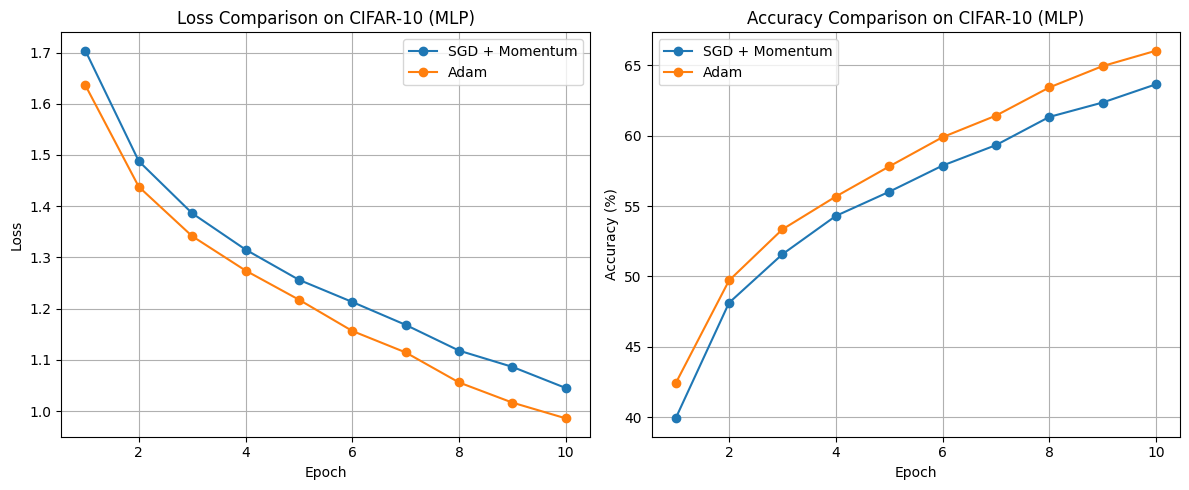


===== FINAL COMPARISON =====
SGD + Momentum - Final Loss: 1.0452, Final Accuracy: 63.65%
Adam - Final Loss: 0.9859, Final Accuracy: 66.03%


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Define transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10 dataset
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

# Create DataLoader
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True
)

# Define MLP model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.net = nn.Sequential(
            nn.Linear(3 * 32 * 32, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)


# Training function
def train(model, optimizer, epochs=10):

    model.to(device)

    loss_fn = nn.CrossEntropyLoss()

    losses = []
    accuracies = []

    for epoch in range(epochs):

        total_loss = 0
        correct = 0
        total = 0

        model.train()

        for imgs, labels in trainloader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(imgs)

            # Calculate loss
            loss = loss_fn(outputs, labels)

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Calculate loss
            total_loss += loss.item()

            # Calculate accuracy
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Average loss
        avg_loss = total_loss / len(trainloader)

        # Accuracy
        accuracy = 100.0 * correct / total

        losses.append(avg_loss)
        accuracies.append(accuracy)

        print(
            f"Epoch {epoch + 1}: "
            f"Loss = {avg_loss:.4f}, "
            f"Accuracy = {accuracy:.2f}%"
        )

    return losses, accuracies


# Train model using SGD with Momentum
print("\n===== SGD WITH MOMENTUM =====")

model_sgd = MLP()

sgd = optim.SGD(
    model_sgd.parameters(),
    lr=0.01,
    momentum=0.9
)

losses_sgd, acc_sgd = train(
    model_sgd,
    sgd,
    epochs=10
)


# Train model using Adam
print("\n===== ADAM OPTIMIZER =====")

model_adam = MLP()

adam = optim.Adam(
    model_adam.parameters(),
    lr=0.001
)

losses_adam, acc_adam = train(
    model_adam,
    adam,
    epochs=10
)


# Plot loss comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(
    range(1, 11),
    losses_sgd,
    marker='o',
    label="SGD + Momentum"
)

plt.plot(
    range(1, 11),
    losses_adam,
    marker='o',
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison on CIFAR-10 (MLP)")
plt.legend()
plt.grid(True)


# Plot accuracy comparison
plt.subplot(1, 2, 2)

plt.plot(
    range(1, 11),
    acc_sgd,
    marker='o',
    label="SGD + Momentum"
)

plt.plot(
    range(1, 11),
    acc_adam,
    marker='o',
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison on CIFAR-10 (MLP)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Print final comparison
print("\n===== FINAL COMPARISON =====")

print(
    f"SGD + Momentum - "
    f"Final Loss: {losses_sgd[-1]:.4f}, "
    f"Final Accuracy: {acc_sgd[-1]:.2f}%"
)

print(
    f"Adam - "
    f"Final Loss: {losses_adam[-1]:.4f}, "
    f"Final Accuracy: {acc_adam[-1]:.2f}%"
)